In [1]:
import matplotlib.font_manager as fm
from matplotlib import rcParams

font_path = '/home/shariat/Documents/fonts/Helvetica.ttf'
fm.fontManager.addfont(font_path)           # add it globally
rcParams['font.family'] = 'Helvetica'  # set default

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress common warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
warnings.filterwarnings("ignore", message=".*X does not have valid feature names.*")

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    accuracy_score
)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [3]:
# ────────────────────────────────────────────────
#         Data Loading & Preparation (Kepler + K2)
# ────────────────────────────────────────────────

data = pd.read_csv('/home/shariat/Astronomy/TTV/Data/PS_2025.10.03_12.37.12.csv', comment='#')

features = [
    'pl_orbper', 'pl_orbsmax', 'pl_rade', 'pl_masse', 'pl_orbeccen',
    'pl_insol', 'pl_eqt', 'pl_orbincl', 'pl_trandep', 'pl_trandur',
    'pl_ratdor', 'pl_ratror', 'st_teff', 'st_rad', 'st_mass'
]
target = 'ttv_flag'

kepler_k2_data = data[data['disc_facility'].isin(['Kepler', 'K2'])].copy()
kepler_k2_data = kepler_k2_data.dropna(subset=[target])

print(f"Kepler + K2 rows: {len(kepler_k2_data)}")
print("Class distribution BEFORE processing:")
print(kepler_k2_data[target].value_counts())
print(kepler_k2_data[target].value_counts(normalize=True).round(4))

# Median imputation for missing values
for col in features:
    if col in kepler_k2_data.columns:
        kepler_k2_data[col] = kepler_k2_data[col].fillna(kepler_k2_data[col].median())

X = kepler_k2_data[features].values
y = kepler_k2_data[target].values.astype(int)

scaler = StandardScaler()
X = scaler.fit_transform(X)

Kepler + K2 rows: 30654
Class distribution BEFORE processing:
ttv_flag
0.0    25810
1.0     4844
Name: count, dtype: int64
ttv_flag
0.0    0.842
1.0    0.158
Name: proportion, dtype: float64


In [4]:
# ────────────────────────────────────────────────
#          Experiment Settings
# ────────────────────────────────────────────────

experiment_name   = "best_model"

use_smote         = True

adaboost_params = {
    'estimator': DecisionTreeClassifier(
        max_depth=9,               # shallow trees → better for AdaBoost
        class_weight='balanced'
    ),
    'n_estimators':     200,
    'learning_rate':    0.8,
    'algorithm':        'SAMME',          # only valid option in scikit-learn ≥1.2
    'random_state':     42
}

In [5]:
# ────────────────────────────────────────────────
#               20-Fold Cross-Validation
# ────────────────────────────────────────────────

n_splits = 20
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

accuracy_scores  = []
precision_scores = []
recall_scores    = []
f1_scores        = []
auc_scores       = []
cm_list          = []
tpr_list         = []
fpr_list         = []

smote = SMOTE(random_state=42, sampling_strategy='auto')

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\nFold {fold+1}/{n_splits}")
    
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    if use_smote:
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
        print(f" After SMOTE → class counts: {np.bincount(y_train_res)}")
    else:
        X_train_res, y_train_res = X_train, y_train
        print(" No SMOTE applied")

    model = AdaBoostClassifier(**adaboost_params)
    model.fit(X_train_res, y_train_res)

    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1]

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    auc = roc_auc_score(y_val, y_pred_proba)

    accuracy_scores.append(acc)
    precision_scores.append(prec)
    recall_scores.append(rec)
    f1_scores.append(f1)
    auc_scores.append(auc)

    cm_list.append(confusion_matrix(y_val, y_pred))

    fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
    common_fpr = np.linspace(0, 1, 100)
    tpr_interp = np.interp(common_fpr, fpr, tpr)
    tpr_list.append(tpr_interp)
    fpr_list.append(common_fpr)

    print(f" Acc: {acc:.4f}  Prec: {prec:.4f}  Rec: {rec:.4f}  F1: {f1:.4f}  AUC: {auc:.4f}")


Fold 1/20
 After SMOTE → class counts: [24519 24519]
 Acc: 0.9217  Prec: 0.7118  Rec: 0.8471  F1: 0.7736  AUC: 0.9622

Fold 2/20
 After SMOTE → class counts: [24519 24519]
 Acc: 0.9276  Prec: 0.7529  Rec: 0.8058  F1: 0.7784  AUC: 0.9471

Fold 3/20
 After SMOTE → class counts: [24519 24519]
 Acc: 0.9230  Prec: 0.7460  Rec: 0.7769  F1: 0.7611  AUC: 0.9528

Fold 4/20
 After SMOTE → class counts: [24519 24519]
 Acc: 0.9269  Prec: 0.7321  Rec: 0.8471  F1: 0.7854  AUC: 0.9626

Fold 5/20
 After SMOTE → class counts: [24519 24519]
 Acc: 0.9211  Prec: 0.7138  Rec: 0.8347  F1: 0.7695  AUC: 0.9512

Fold 6/20
 After SMOTE → class counts: [24519 24519]
 Acc: 0.9139  Prec: 0.7099  Rec: 0.7686  F1: 0.7381  AUC: 0.9452

Fold 7/20
 After SMOTE → class counts: [24519 24519]
 Acc: 0.9282  Prec: 0.7444  Rec: 0.8306  F1: 0.7852  AUC: 0.9578

Fold 8/20
 After SMOTE → class counts: [24519 24519]
 Acc: 0.9152  Prec: 0.7137  Rec: 0.7727  F1: 0.7421  AUC: 0.9473

Fold 9/20
 After SMOTE → class counts: [24519 2

In [6]:
# ────────────────────────────────────────────────
#                  Summary Results
# ────────────────────────────────────────────────

print(f"\n{'═'*40}")
print(f"EXPERIMENT: {experiment_name} (Kepler + K2 data only)")
print(f"SMOTE used: {use_smote}")
print(f"AdaBoost parameters: {adaboost_params}")
print(f"{'═'*40}")
print(f"Accuracy:  {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Precision: {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall:    {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1 Score:  {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"ROC-AUC:   {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
print(f"{'═'*40}\n")


════════════════════════════════════════
EXPERIMENT: best_model (Kepler + K2 data only)
SMOTE used: True
AdaBoost parameters: {'estimator': DecisionTreeClassifier(class_weight='balanced', max_depth=9), 'n_estimators': 200, 'learning_rate': 0.8, 'algorithm': 'SAMME', 'random_state': 42}
════════════════════════════════════════
Accuracy:  0.9212 ± 0.0073
Precision: 0.7234 ± 0.0237
Recall:    0.8128 ± 0.0306
F1 Score:  0.7652 ± 0.0217
ROC-AUC:   0.9534 ± 0.0084
════════════════════════════════════════



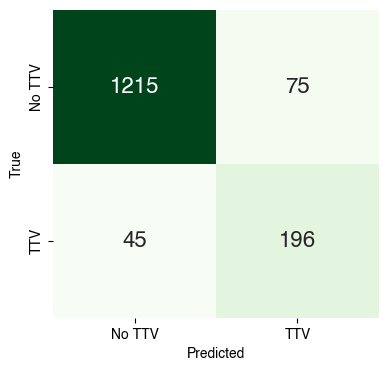

In [7]:
# ────────────────────────────────────────────────
#          Average Confusion Matrix
# ────────────────────────────────────────────────

avg_cm = np.mean(cm_list, axis=0).astype(int)

plt.figure(figsize=(4.2, 4))
sns.heatmap(avg_cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            annot_kws={"size": 16})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks([0.5, 1.5], ['No TTV', 'TTV'])
plt.yticks([0.5, 1.5], ['No TTV', 'TTV'])
plt.savefig('/home/shariat/Astronomy/TTV/AdaBoost/Kepler/figures/kepler_adaboost_20fold_n_200_cm_lr_8.pdf')
plt.show()

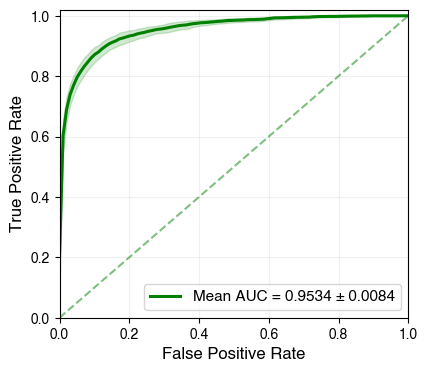

In [8]:
# ────────────────────────────────────────────────
#             Averaged ROC Curve
# ────────────────────────────────────────────────

mean_tpr = np.mean(tpr_list, axis=0)
std_tpr  = np.std(tpr_list, axis=0)
mean_fpr = fpr_list[0]

plt.figure(figsize=(4.5, 4))
plt.plot(mean_fpr, mean_tpr,
         label=f'Mean AUC = {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}',
         color='green', lw=2.2)
plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                 color='green', alpha=0.18)
plt.plot([0, 1], [0, 1], linestyle='--', color='green', alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.18)
plt.xlim([0, 1])
plt.ylim([0, 1.02])
plt.savefig('/home/shariat/Astronomy/TTV/AdaBoost/Kepler/figures/kepler_adaboost_20fold_n_200_roc_lr_8.pdf')
plt.show()

In [9]:
import joblib

# Save the model and scaler
joblib.dump(model, '/home/shariat/Astronomy/TTV/AdaBoost/Kepler/kepler_adaboost_model.pkl')
joblib.dump(scaler, '/home/shariat/Astronomy/TTV/AdaBoost/Kepler/kepler_adaboost_scaler.pkl')

print("Model and scaler saved successfully!")

Model and scaler saved successfully!



════════════════════════════════════════════════════════════
Top 5 Most Important Features (AdaBoost – Kepler + K2)
════════════════════════════════════════════════════════════
     feature  importance
0  pl_orbper     0.17205
1    st_teff     0.15472
2     st_rad     0.14047
3    st_mass     0.11434
4    pl_rade     0.08459


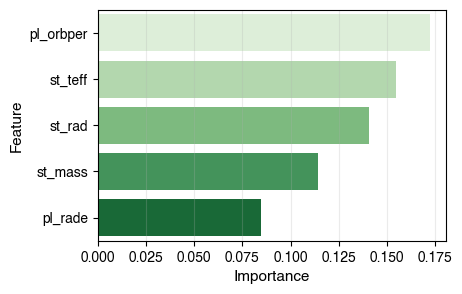

In [10]:
importances = model.feature_importances_
feature_names = features  # your original list of 15 features

# Create DataFrame and sort by importance
fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

# ─── Print only top 5 ──────────────────────────────────────────
print("\n" + "═"*60)
print("Top 5 Most Important Features (AdaBoost – Kepler + K2)")
print("═"*60)
print(fi_df.head(5).round(5))

# ─── Plot only top 5 ───────────────────────────────────────────
plt.figure(figsize=(4.5, 3))  # smaller figure for top 5
sns.barplot(
    data=fi_df.head(5),
    x='importance',
    y='feature',
    palette='Greens'
)
plt.xlabel('Importance', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.grid(axis='x', alpha=0.25)

# Save (adjust path if needed)
plt.savefig('/home/shariat/Astronomy/TTV/figures/AdaBoost_feature.pdf')

plt.show()